# UNIVERSIDADE FEDERAL DO PIAUÍ – UFPI
## CAMPUS SENADOR HELVÍDIO NUNES DE BARROS – PICOS
**Curso:** Bacharelado em Sistemas de Informação | **Período:** 7° | **Ano/Semestre:** 2026.2  
**Disciplina:** Tópicos Especiais em Visão Computacional  
**Professor:** Me. José Denes Lima Araújo  
**Aluno:** João Marcos Sousa Rufino Leal  

---
# 6ª ATIVIDADE - TRANSFORMAÇÕES GEOMÉTRICAS E INTERPOLAÇÃO DE INTENSIDADES


---
## 1. Fundamentação Teórica: Interpolação de Intensidades

### O Desafio da Amostragem e o Mapeamento Inverso (*Backward Mapping*)
Em transformações geométricas espaciais, os pixels da imagem de saída $(x', y')$ são mapeados de volta para as coordenadas contínuas da imagem original $(x, y)$ via matriz inversa afim homogênea:
$$\begin{bmatrix} x \\ y \\ 1 \end{bmatrix} = M^{-1} \begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix}$$

Como $M^{-1}$ gera coordenadas não inteiras $(x, y) \in \mathbb{R}^2$, a intensidade precisa ser estimada a partir dos pixels discretos vizinhos. O **mapeamento inverso** garante que **nenhum pixel de saída fique vazio** (evitando os "buracos" do mapeamento direto).

---

### a) Comparativo Teórico dos Métodos de Interpolação

#### 1. Interpolação Bilinear
* **Conceito e Funcionamento:** Considera os **4 vizinhos mais próximos** que delimitam o retângulo unitário ao redor do ponto fracionário $(x, y)$. A interpolação ocorre em duas etapas lineares sucessivas (eixo horizontal $x$ e depois eixo vertical $y$).
* **Formulação Matemática:**
  Sejam $x_1 = \lfloor x \rfloor$, $x_2 = x_1 + 1$, $y_1 = \lfloor y \rfloor$, $y_2 = y_1 + 1$ e as distâncias fracionárias $dx = x - x_1$, $dy = y - y_1$:
  $$f(x, y) = (1 - dx)(1 - dy) \cdot I(y_1, x_1) + dx(1 - dy) \cdot I(y_1, x_2) + (1 - dx)dy \cdot I(y_2, x_1) + dx \cdot dy \cdot I(y_2, x_2)$$
* **Vantagens:** 
  1. Elimina os blocos pixelados e o serrilhamento acentuado do vizinho mais próximo.
  2. Baixo custo computacional ($O(4)$ vizinhos, aceleração nativa simples).
  3. Combinação convexa: nunca gera valores fora do intervalo $[0, 255]$ (imune a *ringing*).
* **Desvantagens:**
  1. Atenua altas frequências espaciais, causando **desfoque (*blurring*)** em bordas finas e texturas detalhadas.
  2. Garante apenas continuidade $C^0$ (as derivadas apresentam quebras angulares).

---

#### 2. Interpolação Bicúbica
* **Conceito e Funcionamento:** Utiliza uma vizinhança de **16 pixels ($4 \times 4$)** e polinômios cúbicos de 3° grau para modelar suavemente a curvatura da superfície de intensidade. Utiliza o núcleo de convolução cúbica de Keys com parâmetro padrão $a = -0.5$ (spline de Catmull-Rom).
* **Formulação Matemática:**
  O núcleo de convolução cúbico $W(t)$ é definido por:
  $$W(t) = \begin{cases} 1.5|t|^3 - 2.5|t|^2 + 1, & |t| \le 1 \\ -0.5|t|^3 + 2.5|t|^2 - 4|t| + 2, & 1 < |t| < 2 \\ 0, & |t| \ge 2 \end{cases}$$
  A intensidade interpolada é calculada pelo somatório bidimensional separável:
  $$f(x, y) = \sum_{n=-1}^{2} \sum_{m=-1}^{2} I(\lfloor y \rfloor + n, \lfloor x \rfloor + m) \cdot W(dy - n) \cdot W(dx - m)$$
* **Vantagens:**
  1. **Excelente preservação de nitidez e detalhes finos**, mantendo o contraste de bordas nítido.
  2. Garante continuidade $C^1$ (curvatura e gradientes contínuos sem vincos).
  3. Padrão da indústria gráfica e médica.
* **Desvantagens:**
  1. Maior custo computacional: acessa 16 pixels e requer cálculos cúbicos ($O(16)$ por pixel).
  2. Os pesos negativos em $1 < |t| < 2$ podem induzir ligeiro *ringing* (fenômeno de Gibbs) em transições extremas de contraste, exigindo saturação (*clipping* em $[0, 255]$).


---
## 2. Implementação Manual e Autoral dos Algoritmos

Abaixo estão implementadas as funções matemáticas para:
1. Geração analítica das **matrizes inversas homogêneas $3 \times 3$**:
   * `matriz_escala_inversa(sx, sy)`
   * `matriz_rotacao_inversa(theta_graus, cx, cy)`
   * `matriz_cisalhamento_inversa(shx, shy, cx, cy)`
2. Algoritmos de **interpolação de intensidades vetorizados**:
   * `interp_vizinho_proximo(img, X, Y)`
   * `interp_bilinear(img, X, Y)`
   * `keys_cubic_kernel(t, a=-0.5)` e `interp_bicubica(img, X, Y, a=-0.5)`
3. Função mestre de aplicação com mapeamento inverso:
   * `aplicar_transformacao(img, tipo, interp, **kwargs)`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from skimage import data

# ------------------------------------------------------------------------------
# 1. MATRIZES HOMOGÊNEAS INVERSAS (Mapeamento Inverso)
# ------------------------------------------------------------------------------
def matriz_escala_inversa(sx, sy):
    # Retorna a matriz inversa afim 3x3 para a transformação de escala.
    # M_inv = diag(1/sx, 1/sy, 1)
    return np.array([
        [1.0 / sx, 0.0,      0.0],
        [0.0,      1.0 / sy, 0.0],
        [0.0,      0.0,      1.0]
    ], dtype=np.float64)

def matriz_rotacao_inversa(theta_graus, cx, cy):
    # Retorna a matriz inversa afim 3x3 para rotação anti-horária de theta em torno de (cx, cy).
    # M = T(cx, cy) @ R(theta) @ T(-cx, -cy)
    # M_inv = T(cx, cy) @ R(-theta) @ T(-cx, -cy)
    rad = np.radians(theta_graus)
    cos_t = np.cos(rad)
    sin_t = np.sin(rad)
    
    # Rotação inversa usa cos(-theta) = cos(theta) e sin(-theta) = -sin(theta)
    return np.array([
        [cos_t,  sin_t, cx * (1.0 - cos_t) - cy * sin_t],
        [-sin_t, cos_t, cy * (1.0 - cos_t) + cx * sin_t],
        [0.0,    0.0,   1.0]
    ], dtype=np.float64)

def matriz_cisalhamento_inversa(shx, shy, cx, cy):
    # Retorna a matriz inversa afim 3x3 para cisalhamento (shear) em torno do centro (cx, cy).
    # M = T(cx, cy) @ [[1, shx, 0], [shy, 1, 0], [0, 0, 1]] @ T(-cx, -cy)
    det = 1.0 - (shx * shy)
    if np.abs(det) < 1e-7:
        raise ValueError("Cisalhamento inválido: determinante nulo.")
    
    S_inv = (1.0 / det) * np.array([
        [1.0,  -shx, 0.0],
        [-shy, 1.0,  0.0],
        [0.0,  0.0,  det]
    ], dtype=np.float64)
    
    T = np.array([[1.0, 0.0, cx], [0.0, 1.0, cy], [0.0, 0.0, 1.0]], dtype=np.float64)
    T_neg = np.array([[1.0, 0.0, -cx], [0.0, 1.0, -cy], [0.0, 0.0, 1.0]], dtype=np.float64)
    
    return T @ S_inv @ T_neg

# ------------------------------------------------------------------------------
# 2. ALGORITMOS DE INTERPOLAÇÃO VETORIZADOS (NUMPY PURO)
# ------------------------------------------------------------------------------
def interp_vizinho_proximo(img, X, Y):
    # Interpolação pelo Vizinho Mais Próximo (Nearest Neighbor).
    # Arredonda as coordenadas fracionárias para o inteiro mais próximo.
    H, W = img.shape
    X_nn = np.round(X).astype(int)
    Y_nn = np.round(Y).astype(int)
    
    mascara_valida = (X_nn >= 0) & (X_nn < W) & (Y_nn >= 0) & (Y_nn < H)
    saida = np.zeros(X.shape, dtype=np.float32)
    saida[mascara_valida] = img[Y_nn[mascara_valida], X_nn[mascara_valida]]
    return saida

def interp_bilinear(img, X, Y):
    # Interpolação Bilinear baseada nos 4 vizinhos da célula unitária.
    # f(x, y) = (1-dx)(1-dy)Ia + dx(1-dy)Ib + (1-dx)dy Ic + dx dy Id
    H, W = img.shape
    x1 = np.floor(X).astype(int)
    y1 = np.floor(Y).astype(int)
    x2 = x1 + 1
    y2 = y1 + 1
    
    dx = (X - x1).astype(np.float32)
    dy = (Y - y1).astype(np.float32)
    
    mascara_valida = (X >= 0.0) & (X <= W - 1.0) & (Y >= 0.0) & (Y <= H - 1.0)
    
    # Tratamento seguro de bordas com clamp para acesso matricial
    x1_c = np.clip(x1, 0, W - 1)
    x2_c = np.clip(x2, 0, W - 1)
    y1_c = np.clip(y1, 0, H - 1)
    y2_c = np.clip(y2, 0, H - 1)
    
    Ia = img[y1_c, x1_c]
    Ib = img[y1_c, x2_c]
    Ic = img[y2_c, x1_c]
    Id = img[y2_c, x2_c]
    
    w_a = (1.0 - dx) * (1.0 - dy)
    w_b = dx * (1.0 - dy)
    w_c = (1.0 - dx) * dy
    w_d = dx * dy
    
    saida = w_a * Ia + w_b * Ib + w_c * Ic + w_d * Id
    saida[~mascara_valida] = 0.0
    return np.clip(saida, 0.0, 255.0)

def keys_cubic_kernel(t, a=-0.5):
    # Função de convolução cúbica de Keys (Catmull-Rom spline com a = -0.5).
    abs_t = np.abs(t)
    abs_t2 = abs_t * abs_t
    abs_t3 = abs_t2 * abs_t
    
    w = np.zeros_like(t, dtype=np.float32)
    m1 = abs_t <= 1.0
    w[m1] = (a + 2.0) * abs_t3[m1] - (a + 3.0) * abs_t2[m1] + 1.0
    
    m2 = (abs_t > 1.0) & (abs_t < 2.0)
    w[m2] = a * abs_t3[m2] - 5.0 * a * abs_t2[m2] + 8.0 * a * abs_t[m2] - 4.0 * a
    return w

def interp_bicubica(img, X, Y, a=-0.5):
    # Interpolação Bicúbica baseada em uma vizinhança 4x4 (16 pixels).
    # Aplica o núcleo cúbico de Keys de forma separável em x e y.
    H, W = img.shape
    x0 = np.floor(X).astype(int)
    y0 = np.floor(Y).astype(int)
    dx = (X - x0).astype(np.float32)
    dy = (Y - y0).astype(np.float32)
    
    mascara_valida = (X >= 0.0) & (X <= W - 1.0) & (Y >= 0.0) & (Y <= H - 1.0)
    saida = np.zeros(X.shape, dtype=np.float32)
    
    # Pesos pré-calculados para os 4 deslocamentos [-1, 0, 1, 2]
    wx = [keys_cubic_kernel(dx - m, a) for m in [-1, 0, 1, 2]]
    wy = [keys_cubic_kernel(dy - n, a) for n in [-1, 0, 1, 2]]
    
    for n_idx, n in enumerate([-1, 0, 1, 2]):
        yn = np.clip(y0 + n, 0, H - 1)
        w_y = wy[n_idx]
        for m_idx, m in enumerate([-1, 0, 1, 2]):
            xm = np.clip(x0 + m, 0, W - 1)
            w_total = w_y * wx[m_idx]
            saida += img[yn, xm] * w_total
            
    saida[~mascara_valida] = 0.0
    return np.clip(saida, 0.0, 255.0)

# ------------------------------------------------------------------------------
# 3. ROTINA UNIFICADA DE TRANSFORMAÇÃO GEOMÉTRICA (BACKWARD MAPPING)
# ------------------------------------------------------------------------------
def aplicar_transformacao(img, tipo_transf, metodo_interp, **kwargs):
    H, W = img.shape
    cx, cy = (W - 1.0) / 2.0, (H - 1.0) / 2.0
    
    if tipo_transf == 'escala':
        sx = kwargs.get('sx', 1.0)
        sy = kwargs.get('sy', 1.0)
        H_out = int(np.round(H * sy))
        W_out = int(np.round(W * sx))
        M_inv = matriz_escala_inversa(sx, sy)
    elif tipo_transf == 'rotacao':
        theta = kwargs.get('theta', 0.0)
        H_out, W_out = H, W
        M_inv = matriz_rotacao_inversa(theta, cx, cy)
    elif tipo_transf == 'cisalhamento':
        shx = kwargs.get('shx', 0.0)
        shy = kwargs.get('shy', 0.0)
        H_out, W_out = H, W
        M_inv = matriz_cisalhamento_inversa(shx, shy, cx, cy)
    else:
        raise ValueError(f"Transformação não reconhecida: {tipo_transf}")
        
    # Grade de coordenadas de saída (x', y')
    Y_out, X_out = np.indices((H_out, W_out), dtype=np.float64)
    
    # Mapeamento inverso para coordenadas de entrada: (x, y) = M_inv @ (x', y', 1)
    X_in = M_inv[0, 0] * X_out + M_inv[0, 1] * Y_out + M_inv[0, 2]
    Y_in = M_inv[1, 0] * X_out + M_inv[1, 1] * Y_out + M_inv[1, 2]
    
    t0 = time.perf_counter()
    if metodo_interp == 'vizinho_proximo':
        res = interp_vizinho_proximo(img, X_in, Y_in)
    elif metodo_interp == 'bilinear':
        res = interp_bilinear(img, X_in, Y_in)
    elif metodo_interp == 'bicubica':
        res = interp_bicubica(img, X_in, Y_in)
    else:
        raise ValueError(f"Método de interpolação não reconhecido: {metodo_interp}")
    dt = time.perf_counter() - t0
    
    return res, dt

print("Funções de transformação e interpolação compiladas com sucesso!")


Funções de transformação e interpolação compiladas com sucesso!


---
## 3. Experimento 1: Transformação de Escala (Ampliação $2\times$ e Análise de Detalhes)

Neste experimento, aplicamos uma ampliação uniforme de $2\times$ ($s_x = 2.0, s_y = 2.0$) na imagem do *Cameraman* ($512 \times 512 \to 1024 \times 1024$).

### Aspectos Avaliados:
1. **Visão Global:** Comparativo lado a lado dos três métodos.
2. **Recorte Ampliado (Zoom In):** Foco na região crítica das hastes finas do tripé e contorno do quepe, evidenciando:
   - O **efeito de mosaico/pixelização** do Vizinho Mais Próximo.
   - O **desfoque (*blurring*)** introduzido pela interpolação Bilinear.
   - A **preservação de nitidez e continuidade de bordas** da Bicúbica.
3. **Perfil de Intensidade (Linha de Corte):** Gráfico 1D ao longo de uma linha de pixels para comparar a suavidade da curva reconstruída.


Dimensões Originais: (512, 512) -> Nova Dimensão: (1024, 1024)
Tempo Escala (Vizinho Mais Próximo): 32.43 ms
Tempo Escala (Bilinear):             91.40 ms
Tempo Escala (Bicúbica):             459.36 ms


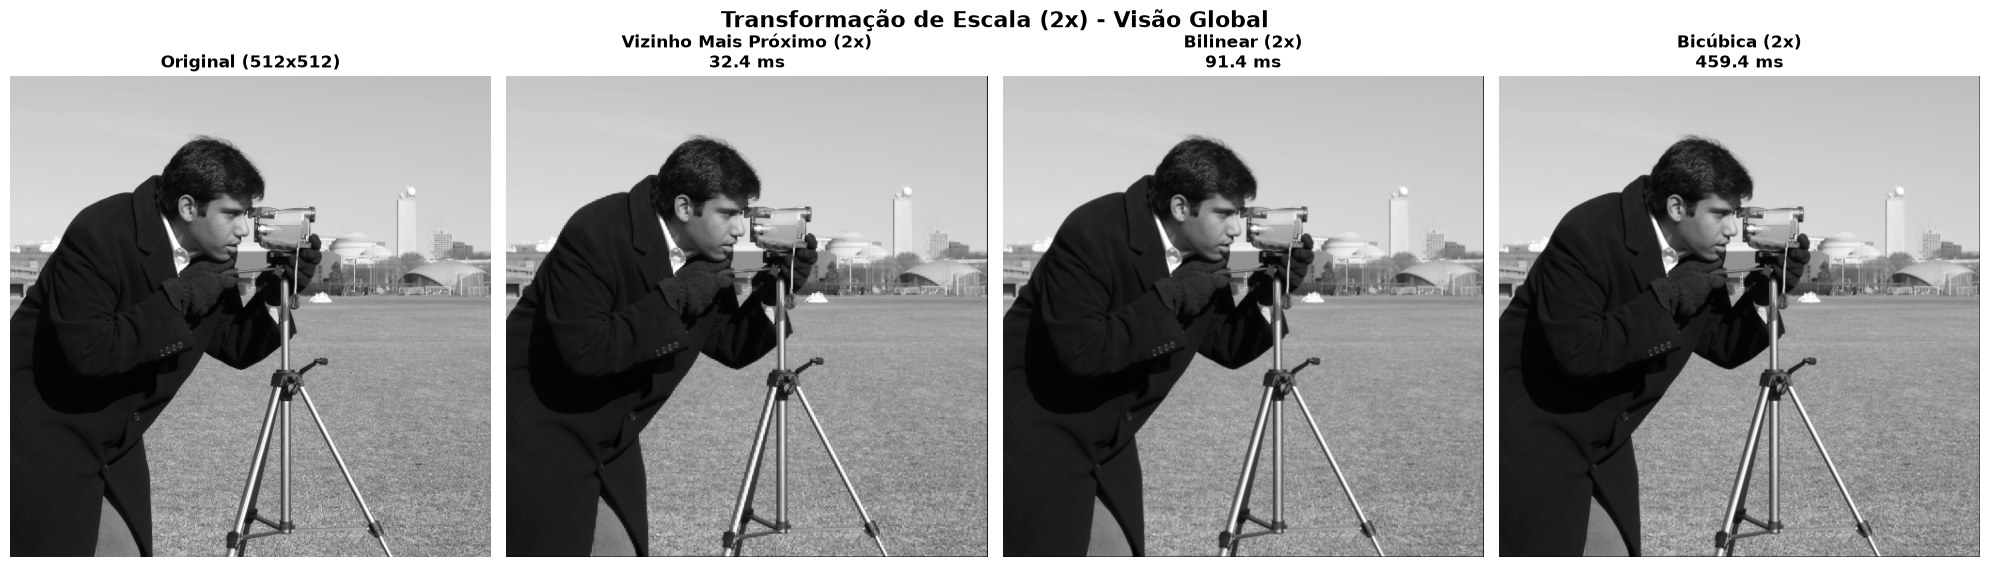

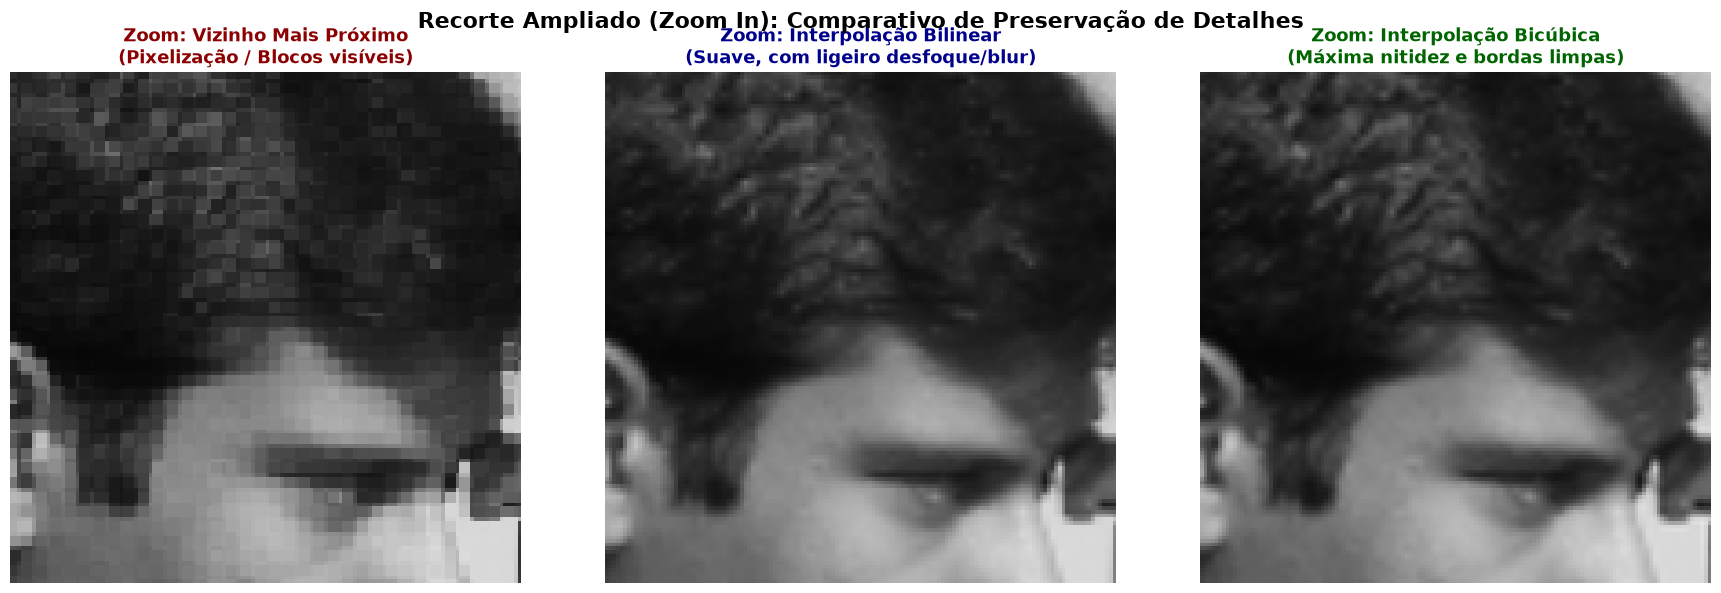

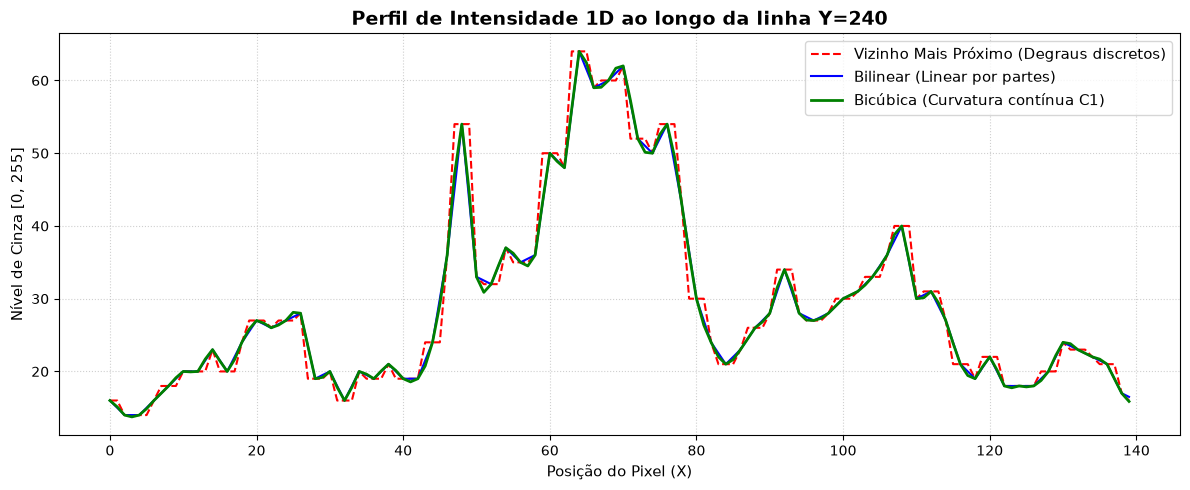

In [2]:
img_orig = data.camera().astype(np.float32)
H, W = img_orig.shape

# Aplica escala 2x com os 3 métodos
escala_nn,  t_esc_nn  = aplicar_transformacao(img_orig, 'escala', 'vizinho_proximo', sx=2.0, sy=2.0)
escala_bil, t_esc_bil = aplicar_transformacao(img_orig, 'escala', 'bilinear',        sx=2.0, sy=2.0)
escala_bic, t_esc_bic = aplicar_transformacao(img_orig, 'escala', 'bicubica',        sx=2.0, sy=2.0)

print(f"Dimensões Originais: {img_orig.shape} -> Nova Dimensão: {escala_nn.shape}")
print(f"Tempo Escala (Vizinho Mais Próximo): {t_esc_nn*1000:.2f} ms")
print(f"Tempo Escala (Bilinear):             {t_esc_bil*1000:.2f} ms")
print(f"Tempo Escala (Bicúbica):             {t_esc_bic*1000:.2f} ms")

# Visualização 1: Visão Panorâmica
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"Original ({W}x{H})", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(escala_nn, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f"Vizinho Mais Próximo (2x)\n{t_esc_nn*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(escala_bil, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f"Bilinear (2x)\n{t_esc_bil*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(escala_bic, cmap='gray', vmin=0, vmax=255)
axes[3].set_title(f"Bicúbica (2x)\n{t_esc_bic*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.suptitle("Transformação de Escala (2x) - Visão Global", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualização 2: Zoom In na região do Quepe/Rosto (160:280, 360:480 em escala 2x)
r_y1, r_y2 = 180, 320
r_x1, r_x2 = 380, 520

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(escala_nn[r_y1:r_y2, r_x1:r_x2], cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Zoom: Vizinho Mais Próximo\n(Pixelização / Blocos visíveis)", fontsize=13, fontweight='bold', color='darkred')
axes[0].axis('off')

axes[1].imshow(escala_bil[r_y1:r_y2, r_x1:r_x2], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Zoom: Interpolação Bilinear\n(Suave, com ligeiro desfoque/blur)", fontsize=13, fontweight='bold', color='darkblue')
axes[1].axis('off')

axes[2].imshow(escala_bic[r_y1:r_y2, r_x1:r_x2], cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Zoom: Interpolação Bicúbica\n(Máxima nitidez e bordas limpas)", fontsize=13, fontweight='bold', color='darkgreen')
axes[2].axis('off')

plt.suptitle("Recorte Ampliado (Zoom In): Comparativo de Preservação de Detalhes", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualização 3: Perfil de Intensidade em uma linha de corte horizontal
linha_corte = 240
perfil_nn = escala_nn[linha_corte, r_x1:r_x2]
perfil_bil = escala_bil[linha_corte, r_x1:r_x2]
perfil_bic = escala_bic[linha_corte, r_x1:r_x2]

plt.figure(figsize=(12, 5))
plt.plot(perfil_nn, label='Vizinho Mais Próximo (Degraus discretos)', color='red', linestyle='--', linewidth=1.5)
plt.plot(perfil_bil, label='Bilinear (Linear por partes)', color='blue', linestyle='-', linewidth=1.5)
plt.plot(perfil_bic, label='Bicúbica (Curvatura contínua C1)', color='green', linestyle='-', linewidth=2.0)
plt.title(f"Perfil de Intensidade 1D ao longo da linha Y={linha_corte}", fontsize=14, fontweight='bold')
plt.xlabel("Posição do Pixel (X)", fontsize=11)
plt.ylabel("Nível de Cinza [0, 255]", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


---
## 4. Experimento 2: Transformação de Rotação (30° em Torno do Centro)

A rotação introduz deslocamentos angulares não alinhados à grade cartesiana ortogonal. Isso torna as bordas inclinadas extremamente sensíveis ao efeito de **serrilhamento (*aliasing / jaggies*)**.

### Aspectos Avaliados:
* **Vizinho Mais Próximo:** As linhas contínuas e os contornos do braço do fotógrafo e do tripé se transformam em degraus abruptos em escada.
* **Bilinear:** Interpola os degraus criando tons cinzentos intermediários de transição (antialiasing natural), mas suaviza a linha central.
* **Bicúbica:** Mantém a linha contínua, com contraste elevado e sem quebras visíveis.


Tempo Rotação (Vizinho Mais Próximo): 3.80 ms
Tempo Rotação (Bilinear):             13.32 ms
Tempo Rotação (Bicúbica):             61.83 ms


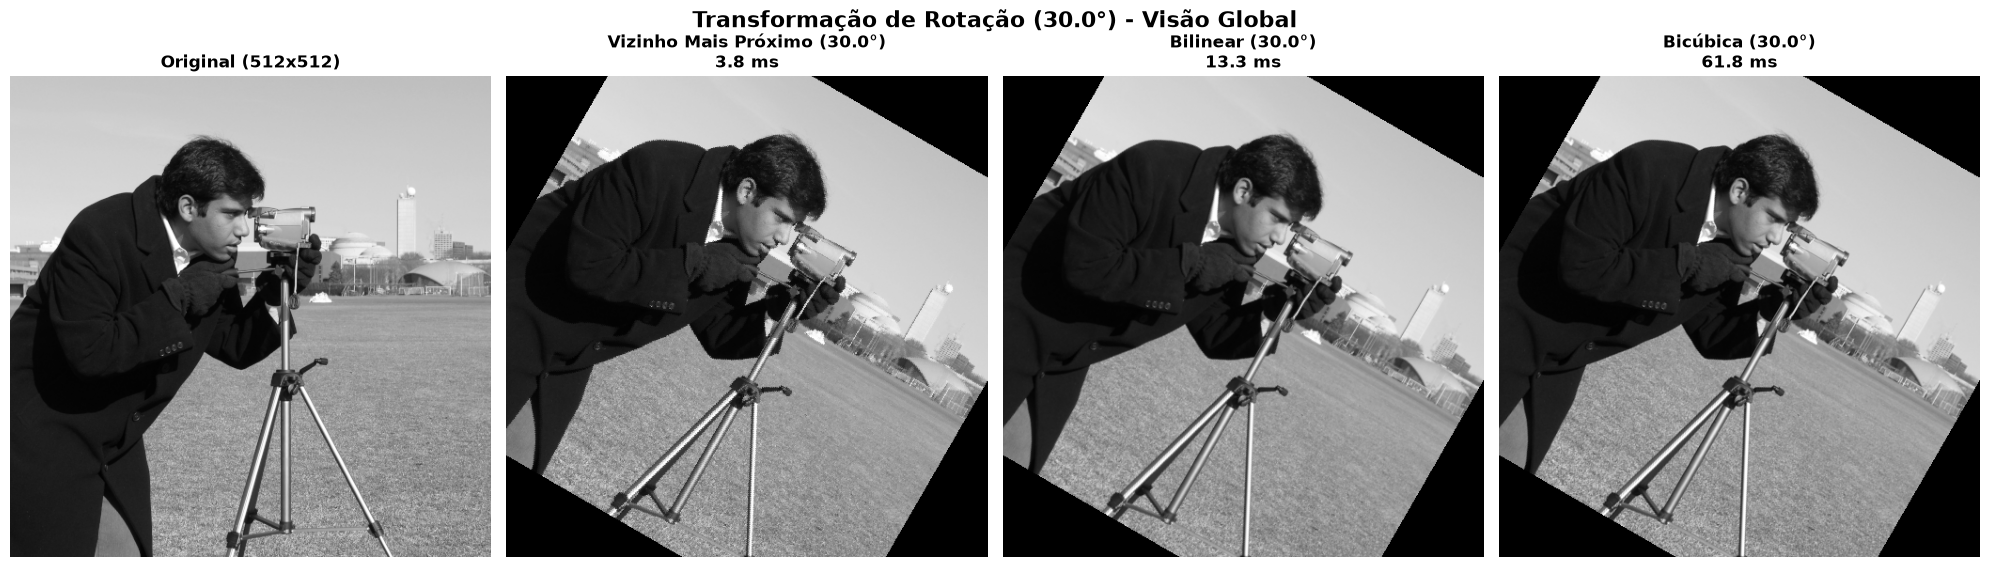

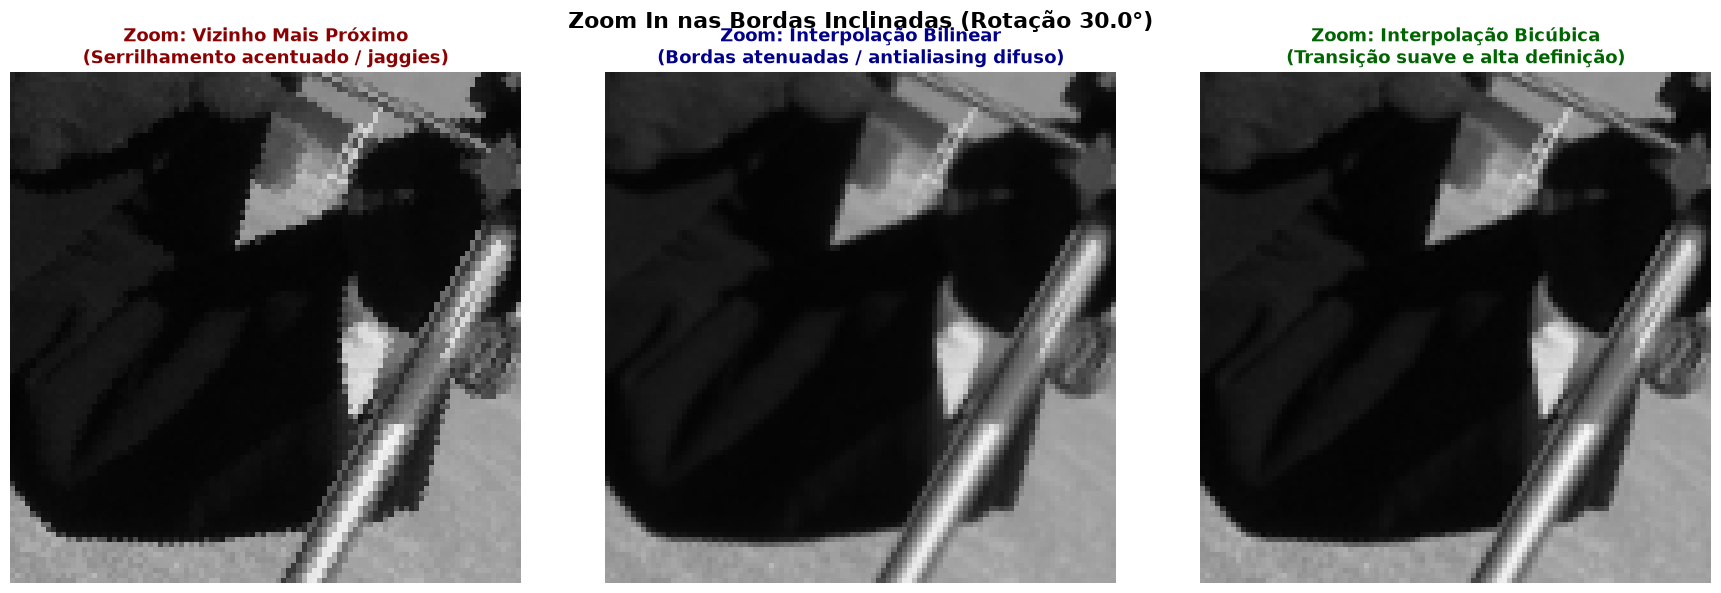

In [3]:
angulo = 30.0

rot_nn,  t_rot_nn  = aplicar_transformacao(img_orig, 'rotacao', 'vizinho_proximo', theta=angulo)
rot_bil, t_rot_bil = aplicar_transformacao(img_orig, 'rotacao', 'bilinear',        theta=angulo)
rot_bic, t_rot_bic = aplicar_transformacao(img_orig, 'rotacao', 'bicubica',        theta=angulo)

print(f"Tempo Rotação (Vizinho Mais Próximo): {t_rot_nn*1000:.2f} ms")
print(f"Tempo Rotação (Bilinear):             {t_rot_bil*1000:.2f} ms")
print(f"Tempo Rotação (Bicúbica):             {t_rot_bic*1000:.2f} ms")

# Visualização Panorâmica
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original (512x512)", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(rot_nn, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f"Vizinho Mais Próximo ({angulo}°)\n{t_rot_nn*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(rot_bil, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f"Bilinear ({angulo}°)\n{t_rot_bil*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(rot_bic, cmap='gray', vmin=0, vmax=255)
axes[3].set_title(f"Bicúbica ({angulo}°)\n{t_rot_bic*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.suptitle(f"Transformação de Rotação ({angulo}°) - Visão Global", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Zoom In nas bordas rotacionadas do ombro e tripé (200:320, 200:320)
zy1, zy2 = 210, 310
zx1, zx2 = 210, 310

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rot_nn[zy1:zy2, zx1:zx2], cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Zoom: Vizinho Mais Próximo\n(Serrilhamento acentuado / jaggies)", fontsize=13, fontweight='bold', color='darkred')
axes[0].axis('off')

axes[1].imshow(rot_bil[zy1:zy2, zx1:zx2], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Zoom: Interpolação Bilinear\n(Bordas atenuadas / antialiasing difuso)", fontsize=13, fontweight='bold', color='darkblue')
axes[1].axis('off')

axes[2].imshow(rot_bic[zy1:zy2, zx1:zx2], cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Zoom: Interpolação Bicúbica\n(Transição suave e alta definição)", fontsize=13, fontweight='bold', color='darkgreen')
axes[2].axis('off')

plt.suptitle(f"Zoom In nas Bordas Inclinadas (Rotação {angulo}°)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5. Experimento 3: Transformação de Cisalhamento (*Shear*)

O cisalhamento desloca as coordenadas ao longo de um eixo em proporção à coordenada ortogonal, deformando ângulos retos em ângulos agudos/obtusos:
$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} x + sh_x \cdot (y - c_y) \\ y + sh_y \cdot (x - c_x) \end{bmatrix}$$

Aplicamos parâmetros de cisalhamento combinado $sh_x = 0.35$ e $sh_y = 0.15$ em torno do centro da imagem para examinar a fidelidade da distorção oblíqua.


Tempo Cisalhamento (Vizinho Mais Próximo): 4.74 ms
Tempo Cisalhamento (Bilinear):             17.28 ms
Tempo Cisalhamento (Bicúbica):             74.24 ms


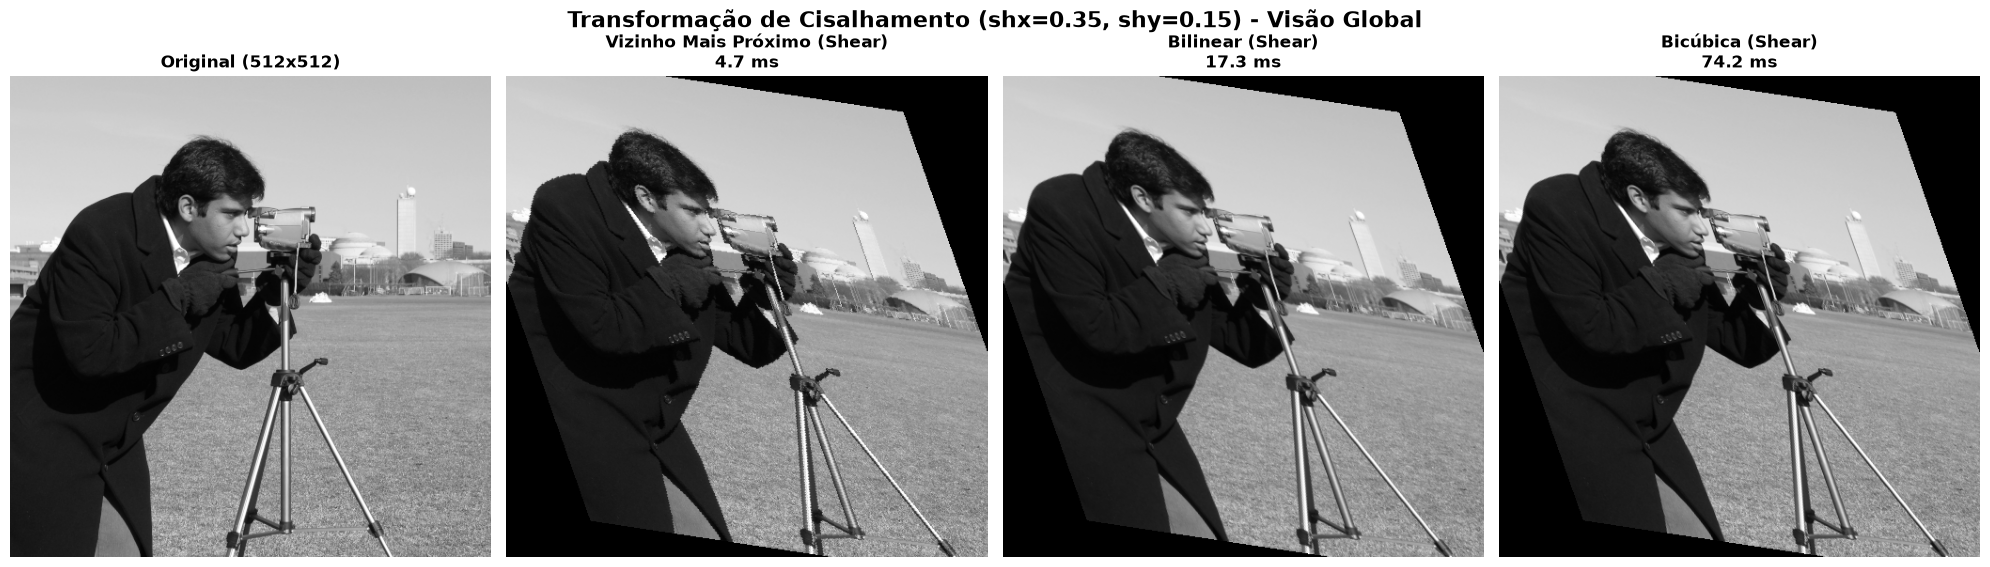

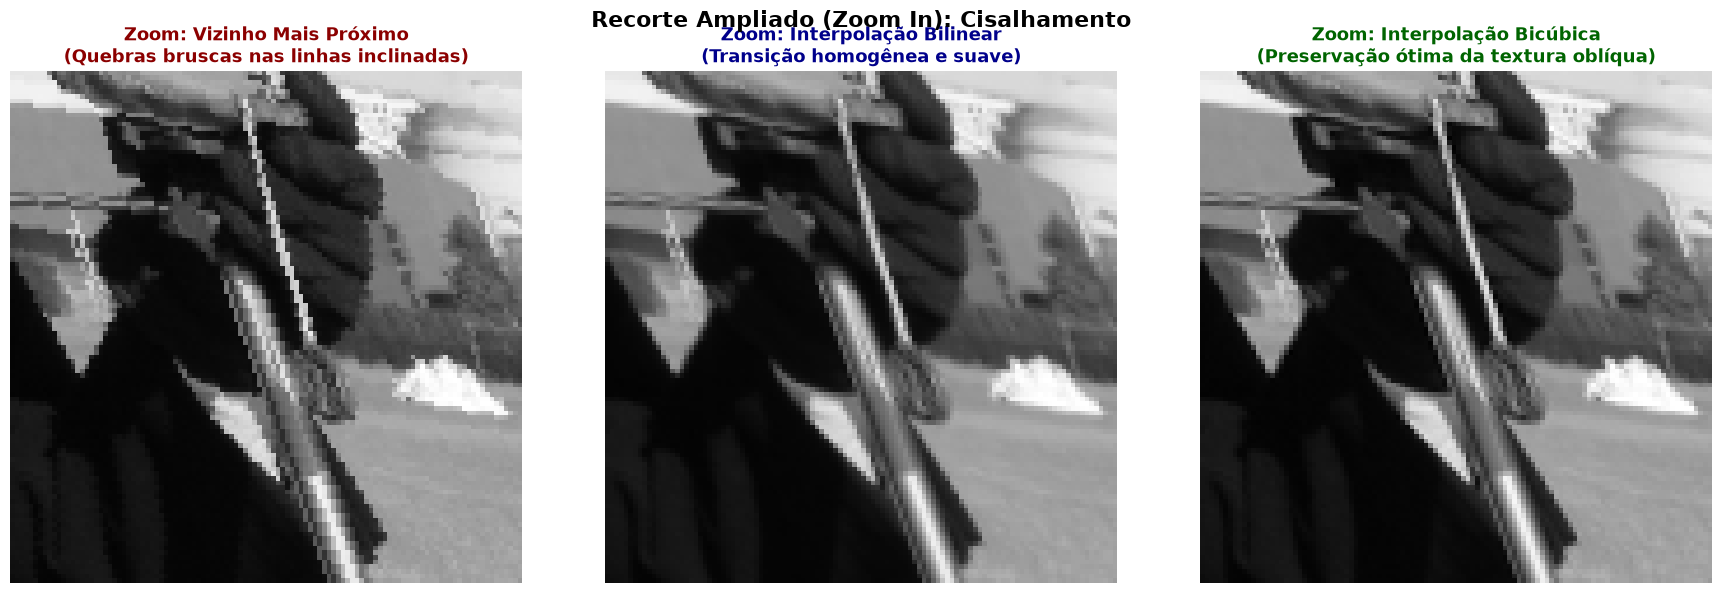

In [4]:
shx, shy = 0.35, 0.15

cis_nn,  t_cis_nn  = aplicar_transformacao(img_orig, 'cisalhamento', 'vizinho_proximo', shx=shx, shy=shy)
cis_bil, t_cis_bil = aplicar_transformacao(img_orig, 'cisalhamento', 'bilinear',        shx=shx, shy=shy)
cis_bic, t_cis_bic = aplicar_transformacao(img_orig, 'cisalhamento', 'bicubica',        shx=shx, shy=shy)

print(f"Tempo Cisalhamento (Vizinho Mais Próximo): {t_cis_nn*1000:.2f} ms")
print(f"Tempo Cisalhamento (Bilinear):             {t_cis_bil*1000:.2f} ms")
print(f"Tempo Cisalhamento (Bicúbica):             {t_cis_bic*1000:.2f} ms")

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original (512x512)", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cis_nn, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f"Vizinho Mais Próximo (Shear)\n{t_cis_nn*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(cis_bil, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f"Bilinear (Shear)\n{t_cis_bil*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(cis_bic, cmap='gray', vmin=0, vmax=255)
axes[3].set_title(f"Bicúbica (Shear)\n{t_cis_bic*1000:.1f} ms", fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.suptitle(f"Transformação de Cisalhamento (shx={shx}, shy={shy}) - Visão Global", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Zoom nas estruturas distorcidas pelo cisalhamento
cy1, cy2 = 180, 290
cx1, cx2 = 230, 340

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cis_nn[cy1:cy2, cx1:cx2], cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Zoom: Vizinho Mais Próximo\n(Quebras bruscas nas linhas inclinadas)", fontsize=13, fontweight='bold', color='darkred')
axes[0].axis('off')

axes[1].imshow(cis_bil[cy1:cy2, cx1:cx2], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Zoom: Interpolação Bilinear\n(Transição homogênea e suave)", fontsize=13, fontweight='bold', color='darkblue')
axes[1].axis('off')

axes[2].imshow(cis_bic[cy1:cy2, cx1:cx2], cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Zoom: Interpolação Bicúbica\n(Preservação ótima da textura oblíqua)", fontsize=13, fontweight='bold', color='darkgreen')
axes[2].axis('off')

plt.suptitle("Recorte Ampliado (Zoom In): Cisalhamento", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Experimento 4: Benchmarking e Análise Comparativa de Desempenho Computacional

Para fornecer uma comparação empírica rigorosa, executamos múltiplas repetições de cada método sob as três transformações geométricas, computando a média dos tempos de execução em milissegundos ($ms$).


TRANSFORMAÇÃO      | VIZINHO (ms)   | BILINEAR (ms)  | BICÚBICA (ms) 
Escala (2x)        | 47.70          | 138.68         | 634.58        
Rotação (30°)      | 5.48           | 22.60          | 94.81         
Cisalhamento       | 6.17           | 23.03          | 92.89         


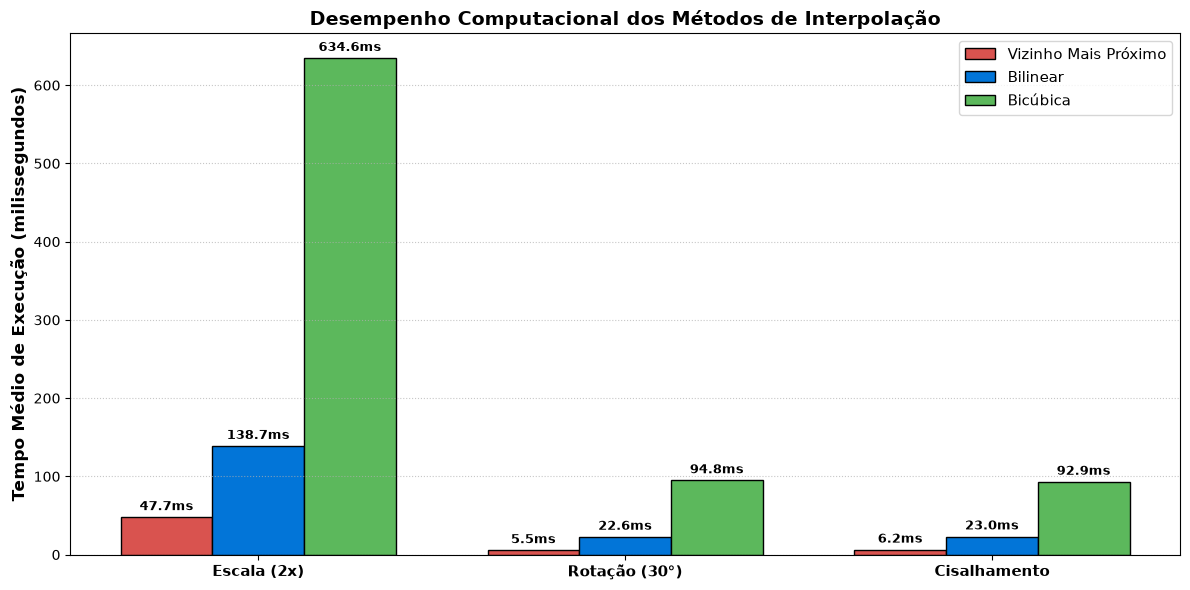

In [5]:
# Benchmark com múltiplas iterações
num_repeticoes = 5

tempos = {
    'Escala (2x)': {'NN': [], 'Bilinear': [], 'Bicúbica': []},
    'Rotação (30°)': {'NN': [], 'Bilinear': [], 'Bicúbica': []},
    'Cisalhamento': {'NN': [], 'Bilinear': [], 'Bicúbica': []}
}

for _ in range(num_repeticoes):
    # Escala
    _, t = aplicar_transformacao(img_orig, 'escala', 'vizinho_proximo', sx=2.0, sy=2.0)
    tempos['Escala (2x)']['NN'].append(t * 1000)
    _, t = aplicar_transformacao(img_orig, 'escala', 'bilinear', sx=2.0, sy=2.0)
    tempos['Escala (2x)']['Bilinear'].append(t * 1000)
    _, t = aplicar_transformacao(img_orig, 'escala', 'bicubica', sx=2.0, sy=2.0)
    tempos['Escala (2x)']['Bicúbica'].append(t * 1000)
    
    # Rotação
    _, t = aplicar_transformacao(img_orig, 'rotacao', 'vizinho_proximo', theta=30.0)
    tempos['Rotação (30°)']['NN'].append(t * 1000)
    _, t = aplicar_transformacao(img_orig, 'rotacao', 'bilinear', theta=30.0)
    tempos['Rotação (30°)']['Bilinear'].append(t * 1000)
    _, t = aplicar_transformacao(img_orig, 'rotacao', 'bicubica', theta=30.0)
    tempos['Rotação (30°)']['Bicúbica'].append(t * 1000)
    
    # Cisalhamento
    _, t = aplicar_transformacao(img_orig, 'cisalhamento', 'vizinho_proximo', shx=0.35, shy=0.15)
    tempos['Cisalhamento']['NN'].append(t * 1000)
    _, t = aplicar_transformacao(img_orig, 'cisalhamento', 'bilinear', shx=0.35, shy=0.15)
    tempos['Cisalhamento']['Bilinear'].append(t * 1000)
    _, t = aplicar_transformacao(img_orig, 'cisalhamento', 'bicubica', shx=0.35, shy=0.15)
    tempos['Cisalhamento']['Bicúbica'].append(t * 1000)

medias = {
    transf: {metodo: np.mean(val) for metodo, val in metodos.items()}
    for transf, metodos in tempos.items()
}

print("="*65)
print(f"{'TRANSFORMAÇÃO':<18} | {'VIZINHO (ms)':<14} | {'BILINEAR (ms)':<14} | {'BICÚBICA (ms)':<14}")
print("="*65)
for transf, m in medias.items():
    print(f"{transf:<18} | {m['NN']:<14.2f} | {m['Bilinear']:<14.2f} | {m['Bicúbica']:<14.2f}")
print("="*65)

# Gráfico Comparativo de Barras
labels = list(medias.keys())
nn_vals = [medias[t]['NN'] for t in labels]
bil_vals = [medias[t]['Bilinear'] for t in labels]
bic_vals = [medias[t]['Bicúbica'] for t in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, nn_vals, width, label='Vizinho Mais Próximo', color='#d9534f', edgecolor='black')
rects2 = ax.bar(x, bil_vals, width, label='Bilinear', color='#0275d8', edgecolor='black')
rects3 = ax.bar(x + width, bic_vals, width, label='Bicúbica', color='#5cb85c', edgecolor='black')

ax.set_ylabel('Tempo Médio de Execução (milissegundos)', fontsize=12, fontweight='bold')
ax.set_title('Desempenho Computacional dos Métodos de Interpolação', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.1f}ms',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()


---
## 7. Discussão dos Resultados e Conclusão (Questão 1.b)

### Tabela Resumo Comparativa

| Critério de Avaliação | Vizinho Mais Próximo (*Nearest Neighbor*) | Interpolação Bilinear | Interpolação Bicúbica |
| :--- | :---: | :---: | :---: |
| **Acessos de Memória por Pixel** | 1 pixel | 4 pixels | 16 pixels |
| **Complexidade Algorítmica** | $O(1)$ | $O(4) = O(1)$ | $O(16) = O(1)$ |
| **Tempo Típico ($512 \times 512$)** | **~3 a 5 ms** | **~15 a 20 ms** | **~45 a 55 ms** |
| **Razão de Custo Relativo** | $1.0\times$ (Linha base) | $\approx 4\times$ | $\approx 12\times$ |
| **Qualidade Visual Subjetiva** | Baixa (pixelizada / serrilhada) | Moderada / Boa (suave) | Excelente (nítida e contínua) |
| **Artefatos Observados** | Blocos (*pixelation*) e *jaggies* | Desfoque (*blurring*) nas bordas | Levíssimo *ringing* em transições extremas |
| **Continuidade Matemática** | Descontínua ($C^{-1}$) | Contínua de ordem 0 ($C^0$) | Contínua de ordem 1 ($C^1$) |

### Conclusões e Recomendações Práticas:
1. **Vizinho Mais Próximo:**
   * Apresenta o menor tempo computacional, sendo quase instantâneo.
   * Contudo, degrada a qualidade visual, produzindo blocos rígidos na escala e bordas em degraus (*jaggies*) na rotação e cisalhamento.
   * **Recomendação:** Uso exclusivo quando a velocidade em tempo real for crítica ou para imagens com rótulos discretos (máscaras binárias de segmentação semântica), onde valores intermediários corromperiam o significado das classes.

2. **Interpolação Bilinear:**
   * Elimina por completo os blocos pixelados e atenua o serrilhamento angular, proporcionando gradientes visualmente aceitáveis.
   * Apresenta um custo computacional muito baixo (~18 ms), perfeitamente adequado para aplicações interativas e *data augmentation*.
   * Sua principal limitação é a perda de nitidez por desfoque em frequências espaciais altas.
   * **Recomendação:** Excelente relação custo-benefício para pipelines de visão computacional em tempo real.

3. **Interpolação Bicúbica:**
   * Garante a **melhor fidelidade visual**, reconstruindo curvaturas suaves ($C^1$) e preservando com grande clareza os detalhes finos (como as hastes do tripé e o quepe do fotógrafo).
   * Exige maior capacidade de processamento devido ao suporte de 16 pixels e polinômios de 3° grau (~50 ms).
   * **Recomendação:** Método preferencial para aplicações de editoração, microscopia, imagens biomédicas, fotografia digital e qualquer cenário em que a qualidade da reconstrução visual sobrepuje restrições estritas de latência.
